In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import json
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import sys
from tqdm import tqdm
sys.path.append("../../bosporus-package/")
from bosporus import *
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['figure.facecolor'] = "#D9D9D9"

In [3]:
with open("fit_palette.json") as f:
    pal = json.load(f)

In [4]:
np.random.seed(41)

In [5]:
measure = "closeness"

In [6]:
with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [7]:
dataset = "TNBC_mibitof:p14_labeledcellData.tiff"
coords = datasets[dataset]

In [8]:
coords = coords[(coords[:, 0] < 1500) & (coords[:,1] < 1500)]
subset = coords /  (np.max(coords, axis=0) - np.min(coords, axis=0)) # [(coords[:, 0] < 1000) & (coords[:,1] < 1000)]

In [9]:
G = nx.Graph()
G.add_nodes_from(range(len(subset)))
for n in G.nodes:
    G.nodes[n]["pos"] = subset[n]
edges = delaunay_edges(subset)
G.add_edges_from(edges)

In [10]:
df =  pd.DataFrame(compute_centrality_measures(edges, len(subset), measures=[measure]))
df["distance"] = distance_to_convex_hull(subset)

In [11]:
d = df["distance"]
C_true = df[measure].values   

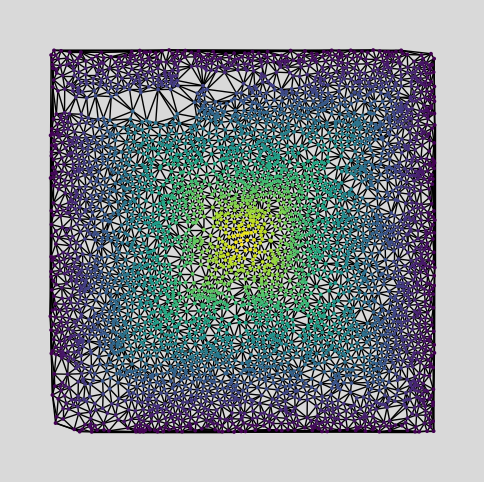

In [18]:
f, ax = plt.subplots(1, figsize=(6, 6))
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), node_color=d, node_size=3, ax=ax)
ax.set_facecolor("#D9D9D9")
f.patch.set_facecolor("#D9D9D9")  # <-- important
plt.savefig("../result_plots/root_cause/dist.svg")

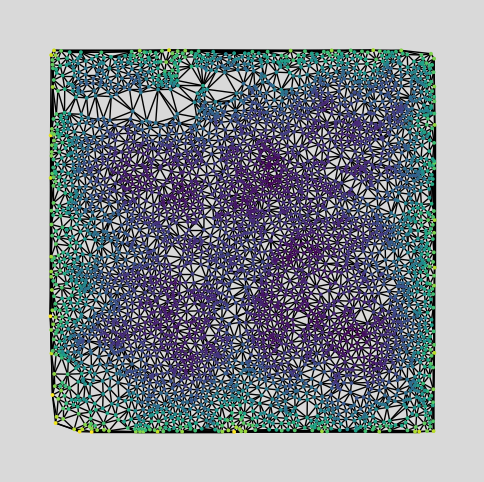

In [19]:
f, ax = plt.subplots(1, figsize=(6, 6))
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), node_color=C_true, node_size=3, ax=ax)
ax.set_facecolor("#D9D9D9")
f.patch.set_facecolor("#D9D9D9")  # <-- important
plt.savefig("../result_plots/root_cause/closeness.svg")

Constant Fit 16405.871894129767 -32807.74378825953 0 0
Piecewise Linear Fit 20172.74201725839 -40337.48403451678 0.11417011113177503 0.07844423776412546
Exponential Saturation Fit 20582.82156497624 -41157.64312995248 0.13832197233784815 0.05962517510357288
Michaelis-Menten Fit 20532.837182358046 -41057.67436471609 0.1544163461929831 0.05484771730896074


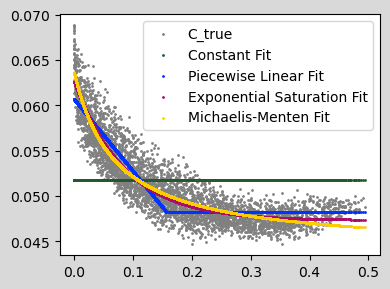

In [14]:
plt.figure(figsize=(4, 3))
plt.scatter(d, C_true, label="C_true", s=1, color="gray")

for fit in ConstantFit, PiecewiseLinearFit, ExponentialSaturationFit, MichaelisMentenFit:
    f = fit(C_true=C_true, d=d)
    f.fit()
    plt.scatter(d, f.C_model, label=f.name, s=1, color=pal[f.name])
    print(f.name, f.log_likelihood, f.AIC, f.observed_effect_strength, f.observed_half_life)
    #if f.name == "Exponential Saturation Fit":
    #    plt.scatter(d, f.correct(), label="C_corrected", s=1, color="black")
plt.tight_layout()
plt.legend()
plt.savefig("../result_plots/root_cause/fits.svg")

In [15]:
f.fit()